In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install kagglehub lightgbm pandas numpy scikit-learn lxml

In [4]:
!pip install shap matplotlib optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.9 MB/s eta 0:00:00


In [5]:
import kagglehub
import os
import pandas as pd
import numpy as np
from lxml import etree
import glob
import lightgbm as lgb

In [6]:
# 2. Refined Generic Parser (for glucose_level, basal)
def parse_generic_timeseries(xml_root, field_name):
    """
    Parses simple time-series tags that use 'ts' and 'value' attributes.
    Works for: <glucose_level> and <basal>.
    """
    records = []
    container = xml_root.find(field_name)
    if container is not None:
        for event in container.findall('event'):
            ts = event.attrib.get('ts')
            val = event.attrib.get('value')
            if ts and val:
                records.append({"timestamp": ts, field_name: float(val)})
    if not records:
        return pd.DataFrame(columns=['timestamp', field_name]).set_index('timestamp')
    return pd.DataFrame(records).set_index('timestamp')

# 3. Specific Meal Parser
def parse_meal(xml_root):
    """
    Parses the <meal> tag, extracting 'ts' for timestamp and 'carbs' for the value.
    """
    records = []
    container = xml_root.find('meal')
    if container is not None:
        for event in container.findall('event'):
            ts = event.attrib.get('ts')
            carbs = event.attrib.get('carbs')
            if ts and carbs:
                record = {'timestamp': ts, 'carbs': float(carbs)}
                if 'type' in event.attrib:
                    record['meal_type'] = event.attrib['type']
                records.append(record)
    if not records:
        return pd.DataFrame(columns=['timestamp', 'carbs', 'meal_type']).set_index('timestamp')
    return pd.DataFrame(records).set_index('timestamp')

# 4. Specific Bolus Parser
def parse_bolus(xml_root):
    """
    Parses the <bolus> tag, using 'ts_begin' as the timestamp and 'dose' as the value.
    """
    records = []
    container = xml_root.find('bolus')
    if container is not None:
        for event in container.findall('event'):
            ts = event.attrib.get('ts_begin')
            dose = event.attrib.get('dose')
            if ts and dose:
                record = {'timestamp': ts, 'bolus_dose': float(dose)}
                if 'bwz_carb_input' in event.attrib:
                    try:
                        record['bwz_carb_input'] = float(event.attrib['bwz_carb_input'])
                    except (ValueError, TypeError):
                        pass
                records.append(record)
    if not records:
        return pd.DataFrame(columns=['timestamp', 'bolus_dose', 'bwz_carb_input']).set_index('timestamp')
    return pd.DataFrame(records).set_index('timestamp')

# 5. Updated Master Parser Function with the FIX
def parse_ohiot1dm_xml_file(filepath):
    """
    Loads one OhioT1DM XML file and calls the appropriate parser for each data type.
    Includes the fix for the timestamp format error.
    """
    tree = etree.parse(filepath)
    root = tree.getroot()

    glucose_df = parse_generic_timeseries(root, 'glucose_level')
    basal_df = parse_generic_timeseries(root, 'basal')
    meal_df = parse_meal(root)
    bolus_df = parse_bolus(root)

    dfs = [glucose_df, basal_df, meal_df, bolus_df]

    df_merged = pd.concat(dfs, axis=1)

    # ---- THE FIX IS HERE ----
    # Explicitly define the date format to match the source XML data.
    # errors='coerce' will turn any un-parseable dates into NaT (Not a Time) instead of crashing.
    df_merged.index = pd.to_datetime(df_merged.index, format='%d-%m-%Y %H:%M:%S', errors='coerce')

    # Drop rows that have bad timestamps after coercion
    df_merged.dropna(axis=0, how='all', subset=df_merged.columns, inplace=True)

    df_merged = df_merged.sort_index()

    return df_merged

# 6. Batch Loader (No changes needed)
def load_all_subjects_xml(folder_path):
    all_dfs = {}
    for f in glob.glob(os.path.join(folder_path, "*.xml")):
        df = parse_ohiot1dm_xml_file(f)
        all_dfs[os.path.basename(f)] = df
    return all_dfs

In [7]:
dataset_path = kagglehub.dataset_download('ryanmouton/ohiot1dm')

100%|██████████| 2.22M/2.22M [00:00<00:00, 36.3MB/s]

Extracting files...


In [8]:
all_subjects_data = load_all_subjects_xml(dataset_path)
df = list(all_subjects_data.values())[0]
display(df.head())

,glucose_level,basal,carbs,meal_type,bolus_dose,bwz_carb_input
timestamp,,,,,,
2021-08-30 00:00:00,NaN,0.83,NaN,NaN,NaN,NaN
2021-08-30 04:00:00,NaN,1.40,NaN,NaN,NaN,NaN
2021-08-30 06:47:44,NaN,NaN,NaN,NaN,3.0,8.0
2021-08-30 07:00:00,NaN,1.20,NaN,NaN,NaN,NaN
2021-08-30 11:53:00,116.0,NaN,NaN,NaN,NaN,NaN


In [10]:
def resample_and_align(df, freq='5min', continuous_cols=None, event_cols=None, categorical_cols=None):
    """
    Correctly resamples and aligns a DataFrame with mixed data types.
    - Applies specific aggregation rules (.mean, .sum, .first) to different columns.
    - Handles NaN filling after aggregation to prevent TypeErrors.
    """
    # 2.1: Handle empty DataFrame
    if df.empty:
        return df

    # 2.2: Define the aggregation rules for each column.
    agg_rules = {}
    if continuous_cols:
        for col in continuous_cols:
            if col in df.columns:
                agg_rules[col] = 'mean'
    if event_cols:
        for col in event_cols:
            if col in df.columns:
                agg_rules[col] = 'sum'
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns:
                agg_rules[col] = 'first' # Take the first non-null category in the window

    # 2.3: Resample the DataFrame using the specific aggregation rules.
    df_resampled = df.resample(freq).agg(agg_rules)

    # 2.4: Process continuous columns: forward-fill missing values.
    if continuous_cols:
        for col in continuous_cols:
            if col in df_resampled.columns:
                df_resampled[col] = df_resampled[col].ffill()

    # 2.5: Process event and categorical columns: fill remaining NaNs.
    # For events, NaN means no event, so fill with 0.
    if event_cols:
        for col in event_cols:
            if col in df_resampled.columns:
                df_resampled[col] = df_resampled[col].fillna(0)
    # For categoricals, NaN means no category, so fill with a placeholder like 'None'.
    if categorical_cols:
         for col in categorical_cols:
            if col in df_resampled.columns:
                df_resampled[col] = df_resampled[col].fillna('None')


    # 2.6: Final cleanup for any remaining NaNs (e.g., at the start of continuous columns).
    df_resampled.fillna(0, inplace=True)

    return df_resampled

In [11]:
CONTINUOUS_COLS = ['glucose_level', 'basal']
EVENT_COLS = ['carbs', 'bolus_dose']
CATEGORICAL_COLS = ['meal_type']
df = resample_and_align(df, continuous_cols=CONTINUOUS_COLS, event_cols=EVENT_COLS, categorical_cols=CATEGORICAL_COLS)
display(df.head())

,glucose_level,basal,carbs,bolus_dose,meal_type
timestamp,,,,,
2021-08-30 00:00:00,0.0,0.83,0.0,0.0,None
2021-08-30 00:05:00,0.0,0.83,0.0,0.0,None
2021-08-30 00:10:00,0.0,0.83,0.0,0.0,None
2021-08-30 00:15:00,0.0,0.83,0.0,0.0,None
2021-08-30 00:20:00,0.0,0.83,0.0,0.0,None


In [12]:
def handle_missing_data(df, cgm_col='glucose_level', max_interp_gap_minutes=60, event_cols=None):
    """
    Handles missing data by interpolating short gaps in continuous signals
    and creating 'time since' features for event signals.

    - Interpolates short gaps (<= max_interp_gap_minutes) in the CGM column using time-weighted linear interpolation.
    - Leaves longer gaps as NaN, for LightGBM to handle.
    - Creates a new 'time_since_last_[event]' feature for each specified event column.
    """
    # 3.1: Create a copy to avoid modifying the original DataFrame
    df_handled = df.copy()

    # 3.2: Handle gaps in the CGM data
    if cgm_col in df_handled.columns:
        # First, interpolate ALL gaps using a time-weighted method.
        # This is better than a simple linear method as it considers the actual time between points.
        df_handled[cgm_col] = df_handled[cgm_col].interpolate(method='time')

        # Now, find gaps that were originally longer than our threshold and revert them to NaN.
        # This block identifies consecutive NaNs in the original data.
        is_na_original = df[cgm_col].isna()
        # Create groups of consecutive NaN values
        na_groups = (is_na_original != is_na_original.shift()).cumsum()

        # Iterate through each group of missing data
        for group_id in na_groups[is_na_original].unique():
            group = df_handled.loc[na_groups == group_id]
            # Calculate the duration of the gap
            gap_duration_minutes = (group.index[-1] - group.index[0]).total_seconds() / 60

            # If the gap is longer than our allowed limit, set the values back to NaN
            if gap_duration_minutes > max_interp_gap_minutes:
                df_handled.loc[group.index, cgm_col] = np.nan

    # 3.3: Create 'time since last event' features for event columns
    if event_cols:
        for col in event_cols:
            if col in df_handled.columns:
                # Find the timestamps where an event occurred (value > 0)
                event_times = df_handled.index[df_handled[col] > 0]

                # If there are no events, the time since is effectively infinite (or a large number).
                # We will fill with a large number and then clean up.
                if event_times.empty:
                    df_handled[f'time_since_{col}'] = np.nan
                    continue

                # Use pandas' merge_asof to find the last event time for each row. It's very fast.
                df_temp = pd.DataFrame(index=df_handled.index)
                events_df = pd.DataFrame(index=event_times)
                merged = pd.merge_asof(df_temp, events_df, left_index=True, right_index=True, direction='backward')

                # Calculate the time difference in minutes
                time_diff = (merged.index - merged.index.to_series().values).total_seconds() / 60
                df_handled[f'time_since_{col}'] = time_diff

    # 3.4: Final cleanup of NaN values from the 'time since' feature
    # A NaN here means no event occurred before it, so we can fill with a large value or 0.
    # Filling with 0 is often simpler, implying "no recent event history".
    time_since_cols = [f'time_since_{col}' for col in (event_cols or [])]
    df_handled[time_since_cols] = df_handled[time_since_cols].fillna(0)

    return df_handled

In [13]:
df = handle_missing_data(df, event_cols=['carbs'], max_interp_gap_minutes=15)
display(df.head())

,glucose_level,basal,carbs,bolus_dose,meal_type,time_since_carbs
timestamp,,,,,,
2021-08-30 00:00:00,0.0,0.83,0.0,0.0,None,0.0
2021-08-30 00:05:00,0.0,0.83,0.0,0.0,None,0.0
2021-08-30 00:10:00,0.0,0.83,0.0,0.0,None,0.0
2021-08-30 00:15:00,0.0,0.83,0.0,0.0,None,0.0
2021-08-30 00:20:00,0.0,0.83,0.0,0.0,None,0.0


In [14]:
def chronological_split(df, train_frac=0.7, val_frac=0.15):
    """
    Splits a time-series DataFrame chronologically into train, validation, and test sets.
    """
    df_sorted = df.sort_index()
    n_total = len(df_sorted)

    train_end_idx = int(n_total * train_frac)
    val_end_idx = train_end_idx + int(n_total * val_frac)

    train_df = df_sorted.iloc[:train_end_idx]
    val_df = df_sorted.iloc[train_end_idx:val_end_idx]
    test_df = df_sorted.iloc[val_end_idx:]

    print("Data split chronologically:")
    print(f"- Training set:   {len(train_df)} rows")
    print(f"- Validation set: {len(val_df)} rows")
    print(f"- Test set:       {len(test_df)} rows")

    return train_df, val_df, test_df

In [59]:
def create_features(df, glucose_col='glucose_level', event_cols=None, physio_cols=None):
    """
    Creates time-series features for a given DataFrame.
    This function should be called independently on train, val, and test sets.
    """
    df_feat = df.copy()

    # Lags, Diffs, and Contextual features are safe as they only use past data within the given df.
    lags = [1, 2, 3, 6, 12, 18, 24, 30, 36, 48, 72]
    for lag in lags:
        df_feat[f'{glucose_col}_lag_{lag*5}min'] = df_feat[glucose_col].shift(lag)

    windows = [6, 12, 18, 24, 36, 48] # 30 min, 1h, 1.5h
    for window in windows:
        win_min = window * 5
        df_feat[f'{glucose_col}_roll_mean_{win_min}min'] = df_feat[glucose_col].rolling(window).mean()
        df_feat[f'{glucose_col}_roll_std_{win_min}min'] = df_feat[glucose_col].rolling(window).std()
        df_feat[f'{glucose_col}_roll_min_{win_min}min'] = df_feat[glucose_col].rolling(window).min()
        df_feat[f'{glucose_col}_roll_max_{win_min}min'] = df_feat[glucose_col].rolling(window).max()
        df_feat[f'{glucose_col}_roll_range_{win_min}min'] = (
            df_feat[f'{glucose_col}_roll_max_{win_min}min'] -
            df_feat[f'{glucose_col}_roll_min_{win_min}min']
        )
    df_feat[f'{glucose_col}_velocity'] = df_feat[glucose_col].diff(1)
    df_feat[f'{glucose_col}_acceleration'] = df_feat[f'{glucose_col}_velocity'].diff(1)
    df_feat[f'{glucose_col}_velocity_5min'] = df_feat[glucose_col].diff(1)
    df_feat[f'{glucose_col}_velocity_15min'] = df_feat[glucose_col].diff(3)
    df_feat[f'{glucose_col}_velocity_30min'] = df_feat[glucose_col].diff(6)

    if event_cols:
        for col in event_cols:
            for window in windows:
                win_size_min = window * 5
                df_feat[f'{col}_roll_sum_{win_size_min}min'] = df_feat[col].rolling(window=window).sum()

    df_feat[f'{glucose_col}_velocity'] = df_feat[glucose_col].diff(1)
    df_feat[f'{glucose_col}_acceleration'] = df_feat[f'{glucose_col}_velocity'].diff(1)

    df_feat['minute'] = df_feat.index.minute
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
    df_feat['is_night'] = ((df_feat.index.hour >= 22) | (df_feat.index.hour <= 6)).astype(int)
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)


    return df_feat

In [49]:
def create_target(df, glucose_col='glucose_level', horizon_minutes=30):
    """
    Creates the target variable for a given DataFrame.
    """
    df_target = df.copy()

    freq_minutes = 5 # Assuming 5-minute frequency
    horizon_steps = int(horizon_minutes / freq_minutes)

    df_target['target'] = df_target[glucose_col].shift(-horizon_steps)

    # Drop rows where the target is missing (at the end of the DataFrame)
    # Also drop rows where features are missing (at the start of the DataFrame from lags/rolling)
    df_target.dropna(inplace=True)

    return df_target

In [64]:
from sklearn.preprocessing import LabelEncoder

def fix_categorical_columns(df):
    """
    Fixes categorical columns for LightGBM compatibility
    """
    df_fixed = df.copy()

    # Find all object/string columns
    categorical_columns = df_fixed.select_dtypes(include=['object']).columns

    print(f"Found categorical columns: {list(categorical_columns)}")

    for col in categorical_columns:
        # Handle NaN values first
        df_fixed[col] = df_fixed[col].fillna('Unknown')

        # Convert to numeric using label encoding
        le = LabelEncoder()
        df_fixed[col] = le.fit_transform(df_fixed[col])

        print(f"✓ Converted {col} to numeric (0 to {df_fixed[col].max()})")

    return df_fixed

In [65]:
# CORRECT WORKFLOW:
# Step 1: Handle missing data (but don't create target yet)
df = handle_missing_data(df)

# Step 2: Split FIRST (chronologically)
train_set, val_set, test_set = chronological_split(df)

# Step 3: Create features and target separately for each split
def process_split(split_df):
    # Create features
    featured_df = create_features(split_df, event_cols=['carbs'])
    df_fixed = fix_categorical_columns(featured_df)
    # Then create target
    final_df = create_target(df_fixed)
    return final_df

train_set = process_split(train_set)
val_set = process_split(val_set)
test_set = process_split(test_set)


Data split chronologically:
- Training set:   9273 rows
- Validation set: 1987 rows
- Test set:       1988 rows
Found categorical columns: ['meal_type']
✓ Converted meal_type to numeric (0 to 5)
Found categorical columns: ['meal_type']
✓ Converted meal_type to numeric (0 to 4)
Found categorical columns: ['meal_type']
✓ Converted meal_type to numeric (0 to 5)


In [66]:
print("\nFinal shapes of the datasets ready for modeling:")
print(f"Train set:      {train_set.shape}")
print(f"Validation set: {val_set.shape}")
print(f"Test set:       {test_set.shape}")


Final shapes of the datasets ready for modeling:
Train set:      (9195, 66)
Validation set: (1909, 66)
Test set:       (1910, 66)


In [67]:
print(train_set.columns)

Index(['glucose_level', 'basal', 'carbs', 'bolus_dose', 'meal_type',
       'time_since_carbs', 'glucose_level_lag_5min', 'glucose_level_lag_10min',
       'glucose_level_lag_15min', 'glucose_level_lag_30min',
       'glucose_level_lag_60min', 'glucose_level_lag_90min',
       'glucose_level_lag_120min', 'glucose_level_lag_150min',
       'glucose_level_lag_180min', 'glucose_level_lag_240min',
       'glucose_level_lag_360min', 'glucose_level_roll_mean_30min',
       'glucose_level_roll_std_30min', 'glucose_level_roll_min_30min',
       'glucose_level_roll_max_30min', 'glucose_level_roll_range_30min',
       'glucose_level_roll_mean_60min', 'glucose_level_roll_std_60min',
       'glucose_level_roll_min_60min', 'glucose_level_roll_max_60min',
       'glucose_level_roll_range_60min', 'glucose_level_roll_mean_90min',
       'glucose_level_roll_std_90min', 'glucose_level_roll_min_90min',
       'glucose_level_roll_max_90min', 'glucose_level_roll_range_90min',
       'glucose_level_roll_mea

In [68]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

In [69]:
def train_lgbm_model(train_df, val_df, features, target):
    """
    Trains a LightGBM model using a training and validation set.
    Implements early stopping to prevent overfitting.
    """
    # 7.1: Separate features (X) and target (y) for both sets
    X_train, y_train = train_df[features], train_df[target]
    X_val, y_val = val_df[features], val_df[target]

    # 7.2: Define the LightGBM model parameters
    # These are good starting parameters that you can tune later.
    lgbm_params = {
        'objective': 'regression_l1',  # L1 loss is often more robust to outliers than L2 (rmse)
        'metric': 'rmse',
        'n_estimators': 2000,          # High number, will be stopped by early stopping
        'learning_rate': 0.01,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'num_leaves': 31,
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }

    # 7.3: Instantiate and train the model
    model = lgb.LGBMRegressor(**lgbm_params)

    print("--- Starting Model Training ---")
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=True)]
    )

    # 7.4: Evaluate the model on the validation set using the best iteration
    val_preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    print(f"\nValidation RMSE of the best model: {rmse:.4f}")

    return model

In [70]:
# feature_columns = ['glucose_level_lag_5min', 'glucose_level_velocity']
feature_columns = ['glucose_level', 'basal', 'carbs', 'bolus_dose', 'meal_type',
       'time_since_carbs', 'glucose_level_lag_5min', 'glucose_level_lag_10min',
       'glucose_level_lag_15min', 'glucose_level_lag_30min',
       'glucose_level_lag_60min', 'glucose_level_lag_90min',
       'glucose_level_lag_120min', 'glucose_level_lag_150min',
       'glucose_level_lag_180min', 'glucose_level_lag_240min',
       'glucose_level_lag_360min', 'glucose_level_roll_mean_30min',
       'glucose_level_roll_std_30min', 'glucose_level_roll_min_30min',
       'glucose_level_roll_max_30min', 'glucose_level_roll_range_30min',
       'glucose_level_roll_mean_60min', 'glucose_level_roll_std_60min',
       'glucose_level_roll_min_60min', 'glucose_level_roll_max_60min',
       'glucose_level_roll_range_60min', 'glucose_level_roll_mean_90min',
       'glucose_level_roll_std_90min', 'glucose_level_roll_min_90min',
       'glucose_level_roll_max_90min', 'glucose_level_roll_range_90min',
       'glucose_level_roll_mean_120min', 'glucose_level_roll_std_120min',
       'glucose_level_roll_min_120min', 'glucose_level_roll_max_120min',
       'glucose_level_roll_range_120min', 'glucose_level_roll_mean_180min',
       'glucose_level_roll_std_180min', 'glucose_level_roll_min_180min',
       'glucose_level_roll_max_180min', 'glucose_level_roll_range_180min',
       'glucose_level_roll_mean_240min', 'glucose_level_roll_std_240min',
       'glucose_level_roll_min_240min', 'glucose_level_roll_max_240min',
       'glucose_level_roll_range_240min', 'glucose_level_velocity',
       'glucose_level_acceleration', 'glucose_level_velocity_5min',
       'glucose_level_velocity_15min', 'glucose_level_velocity_30min',
       'carbs_roll_sum_30min', 'carbs_roll_sum_60min', 'carbs_roll_sum_90min',
       'carbs_roll_sum_120min', 'carbs_roll_sum_180min',
       'carbs_roll_sum_240min', 'minute', 'hour', 'dayofweek', 'is_weekend',
       'is_night', 'hour_sin', 'hour_cos']
target_column = 'target'
trained_model = train_lgbm_model(train_set, val_set, feature_columns, target_column)

--- Starting Model Training ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[625]	valid_0's rmse: 19.3177

Validation RMSE of the best model: 19.3177


In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import matplotlib.pyplot as plt

def evaluate_on_test_set(model, test_df, features, target):
    """
    Evaluates the final model's performance on the unseen test set.
    """
    # 8.1: Separate the features and the true target values from the test set
    X_test = test_df[features]
    y_test = test_df[target]

    # 8.2: Use the trained model to make predictions on the test features
    y_pred = model.predict(X_test)

    # 8.3: Calculate the performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print("--- Model Performance on Unseen Test Set ---")
    print(f"- Test RMSE: {rmse:.4f}")
    print(f"- Test MAE:  {mae:.4f}")
    print("------------------------------------------")

    return y_pred, y_test

# --- Part 2: Feature Importance and Interpretation Function ---

def interpret_model_on_test_set(model, test_df, features):
    """
    Generates feature importance plots to interpret the model's behavior on the test set.
    """
    X_test = test_df[features]

    # 8.4: Plot LightGBM's built-in feature importance
    print("\n--- LightGBM Feature Importance (Gain) ---")
    lgb.plot_importance(model, importance_type='gain', max_num_features=20, figsize=(10, 8),
                        title='Top 20 Features by Gain')
    plt.show()

    # 8.5: Generate SHAP plots for deeper interpretation
    print("\n--- SHAP Summary Plots ---")
    # Initialize SHAP and create an explainer
    shap.initjs()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # SHAP summary plot (bar format)
    print("Average impact of each feature on model output:")
    shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

    # SHAP summary plot (dot format) - shows feature value impact
    print("\nImpact of each feature on individual predictions:")
    shap.summary_plot(shap_values, X_test, max_display=20)


In [71]:
# 2. Call the evaluation functions with your actual test_set and trained_model
print("--- Starting Final Evaluation ---")
test_predictions, test_true_values = evaluate_on_test_set(
    model=trained_model, # Replace with your 'trained_model'
    test_df=test_set,
    features=feature_columns,
    target=target_column
)

--- Starting Final Evaluation ---
--- Model Performance on Unseen Test Set ---
- Test RMSE: 20.1798
- Test MAE:  14.5319
------------------------------------------



--- LightGBM Feature Importance (Gain) ---


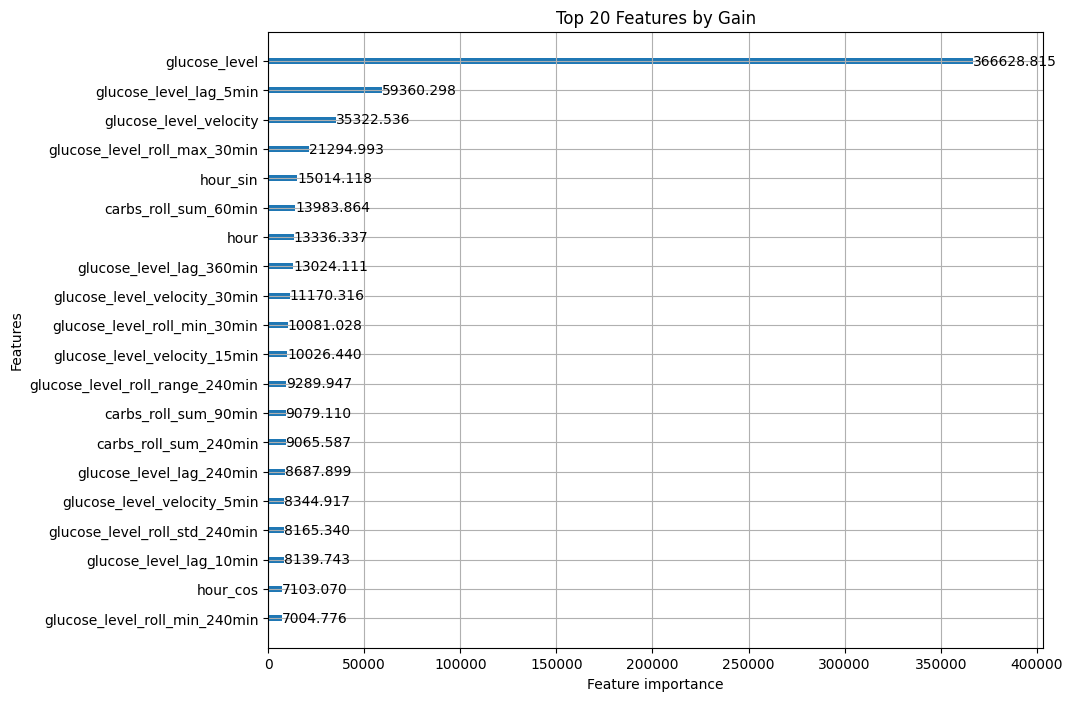


--- SHAP Summary Plots ---


Average impact of each feature on model output:


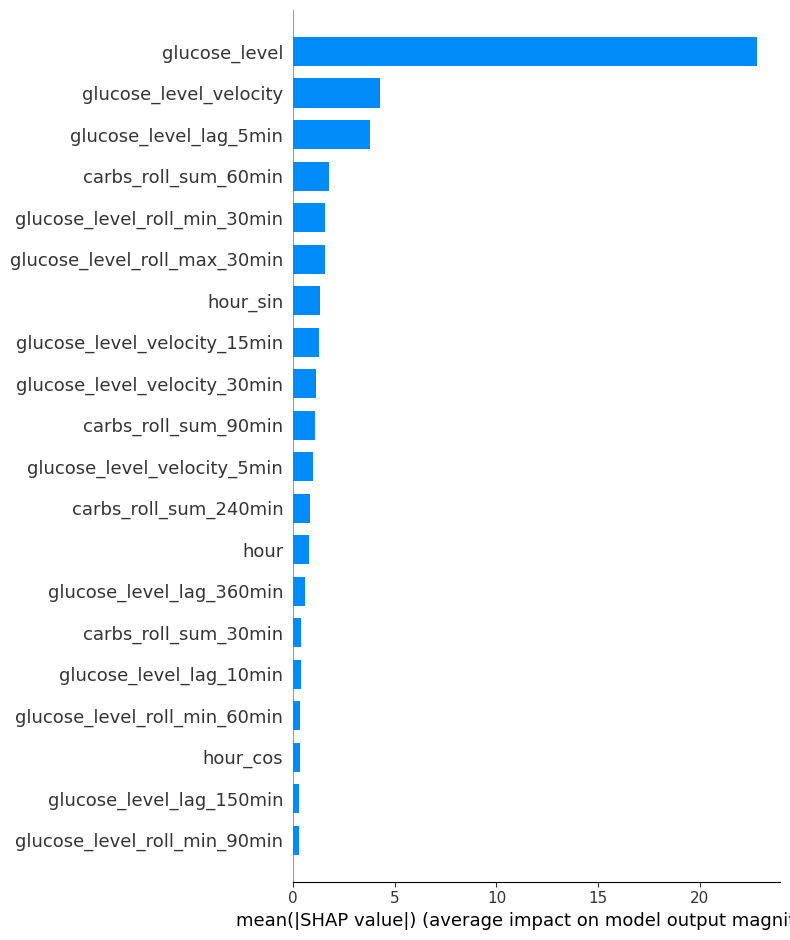


Impact of each feature on individual predictions:


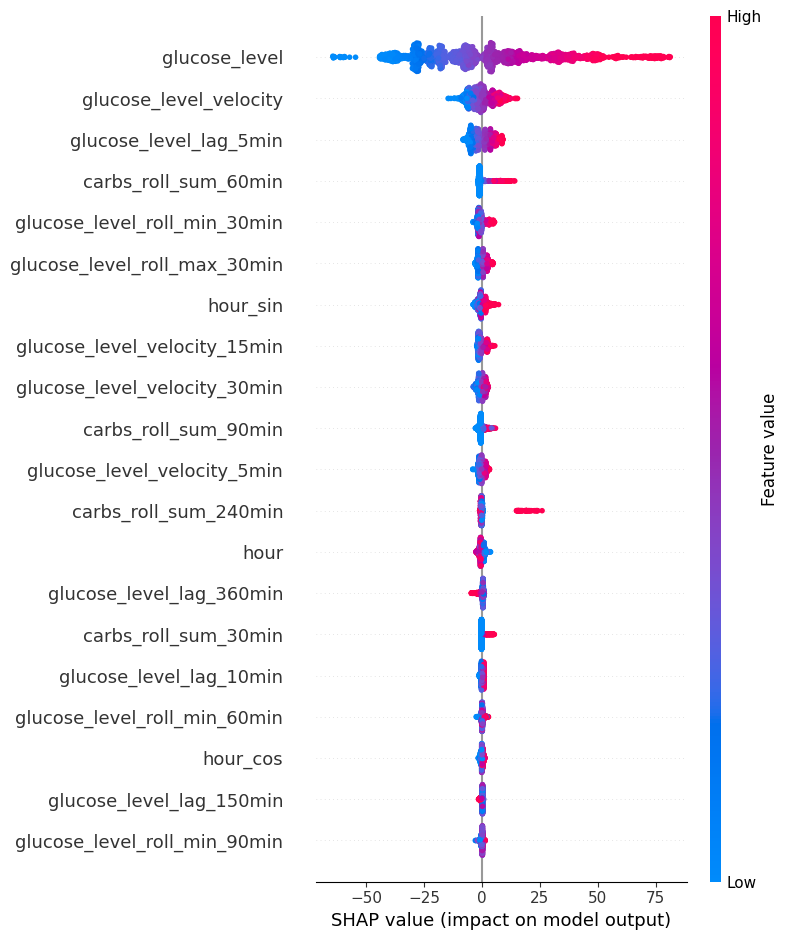

In [72]:
interpret_model_on_test_set(
    model=trained_model, # Replace with your 'trained_model'
    test_df=test_set,
    features=feature_columns
)